In [1]:
import os
import numpy as np
import pandas as pd
import torch 
from torch import nn
from torch.utils.data import DataLoader

import pytorch_lightning as pl
from pytorch_lightning import callbacks 
from pytorch_lightning import loggers as pl_loggers

import models
from reader import Pdyn_ExtractDataset
from matplotlib import pyplot as pl

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import pl as pl_fun

# read data

In [4]:
pt_path = 'dataExample.pt'

train_DS = Pdyn_ExtractDataset(Data_pt=pt_path, n_grid=300, collocation_points=300, n_repeat=10)
# val_DS= Pdyn_ExtractDataset(Data_pt=pt_path, n_grid=300, collocation_points=600, n_repeat=1)

train_iter = iter(DataLoader(train_DS, batch_size=1, num_workers=4))

# val_DL = DataLoader(val_DS, batch_size=1, num_workers=4)

In [10]:
data_batch = next(train_iter)

# version 0

In [11]:
main_dir = "/ssd/users/wergillius/Project/PINN_dynamics"

# v3
ckpt0 = "../logs/Cspline_PINN_RandMiniB/lightning_logs/version_0/checkpoints/epoch=172-total_loss=0.50371242.ckpt"
modelv0 = models.Cspline_PINN.load_from_checkpoint(ckpt0)

/ssd/users/wergillius/.conda/envs/pytorch/lib/python3.8/site-packages/pytorch_lightning/utilities/parsing.py:268: UserWarning: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.
  rank_zero_warn(


In [14]:
s_col, t_col, s_all, t_b, u_b, Mean, Var = modelv0.get_data(data_batch, False)

[10.528237 10.369932 11.536549 12.920536 13.555336 14.072313]
[ 9.602811  10.438831  11.037735  11.5617075 12.029749  12.487436 ]


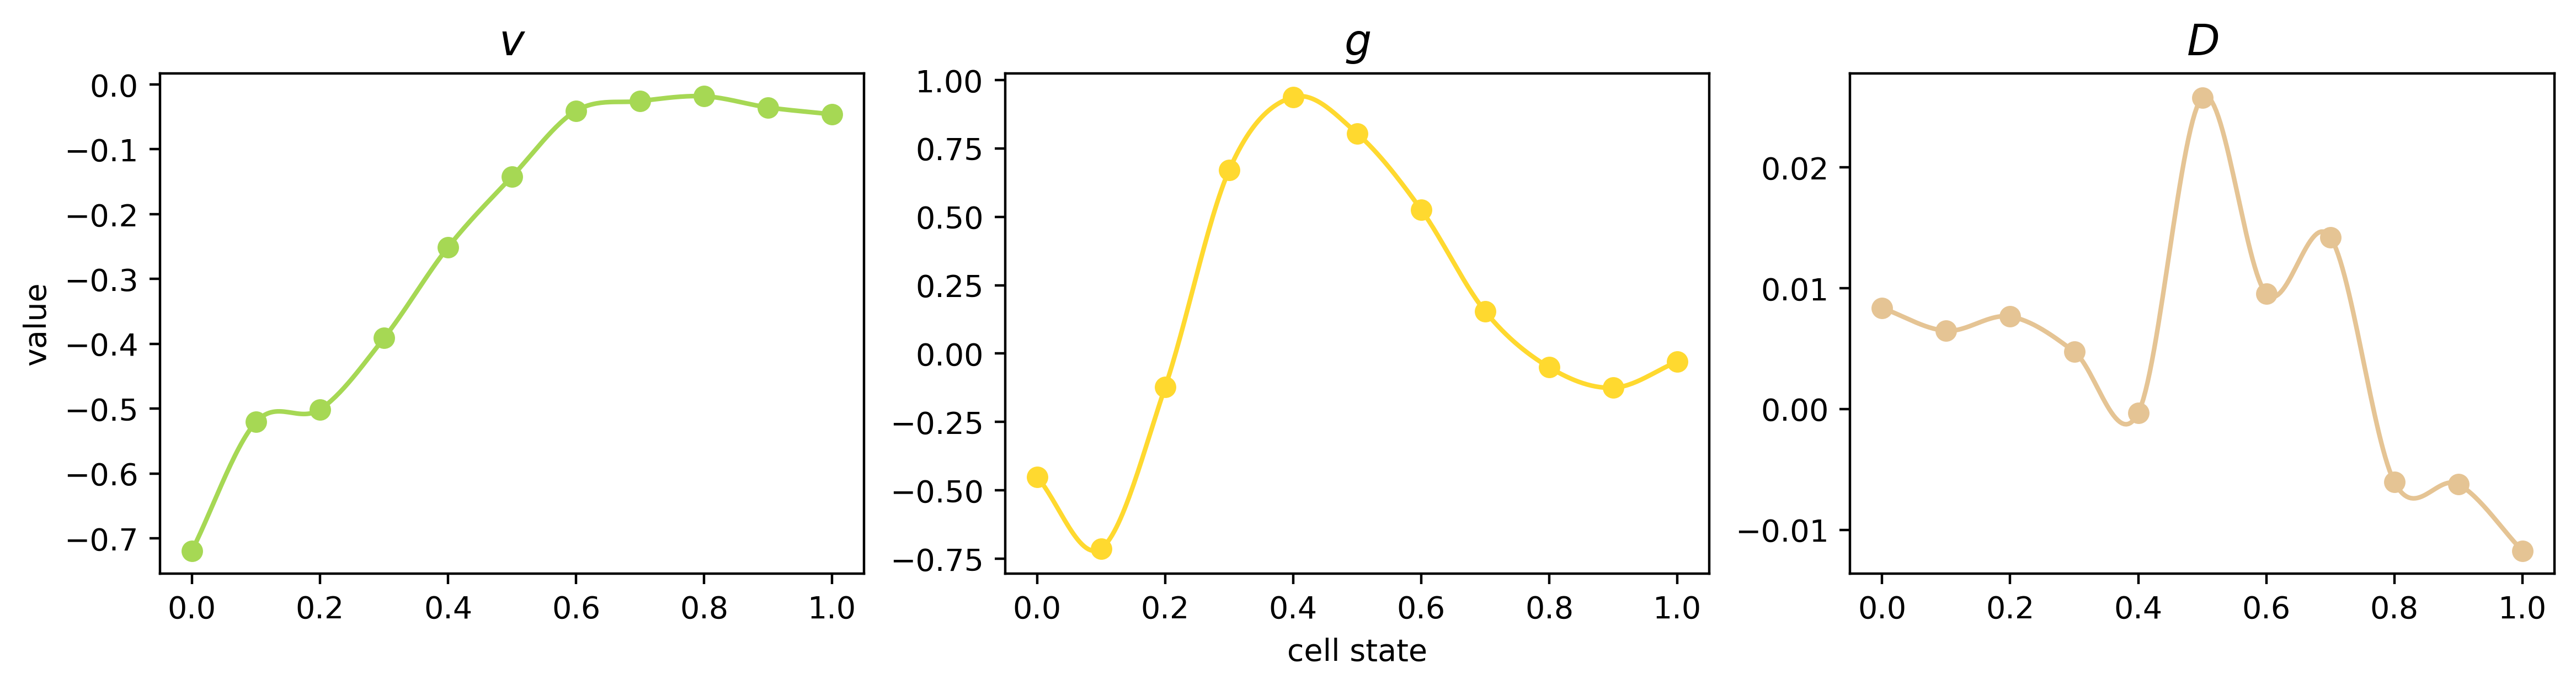

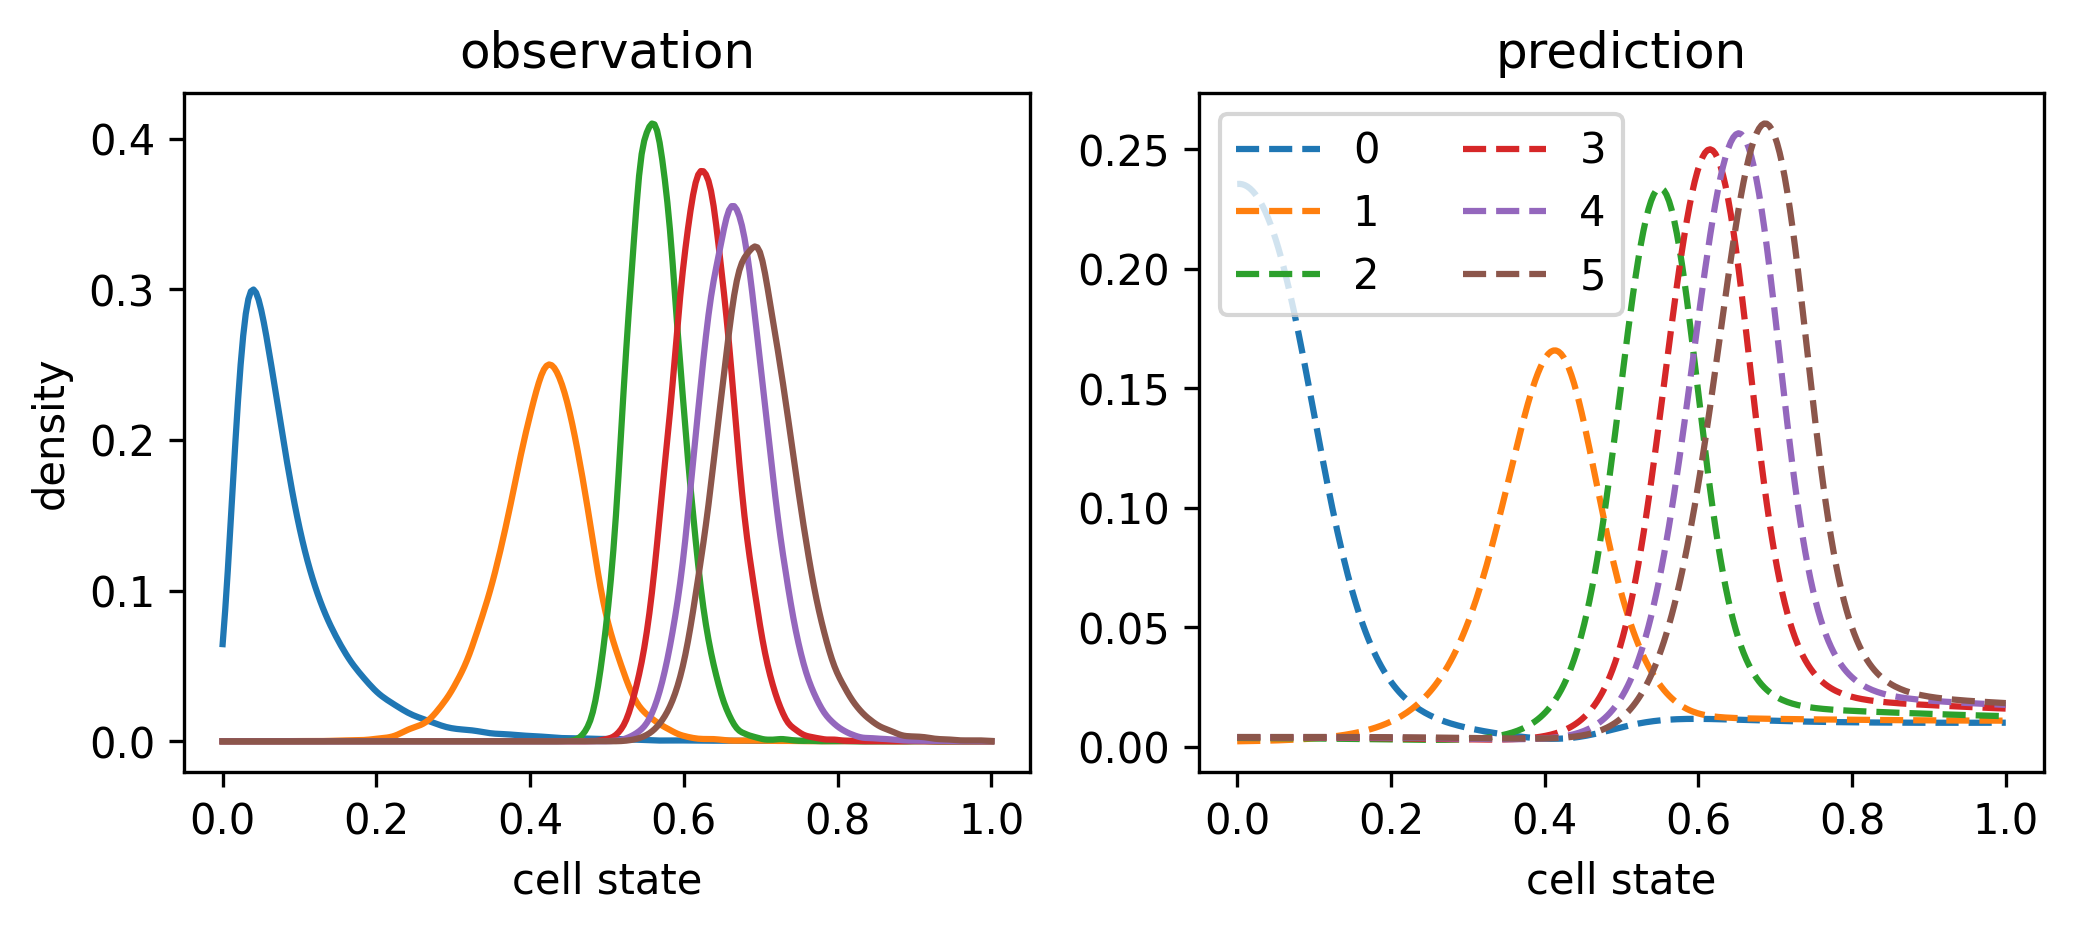

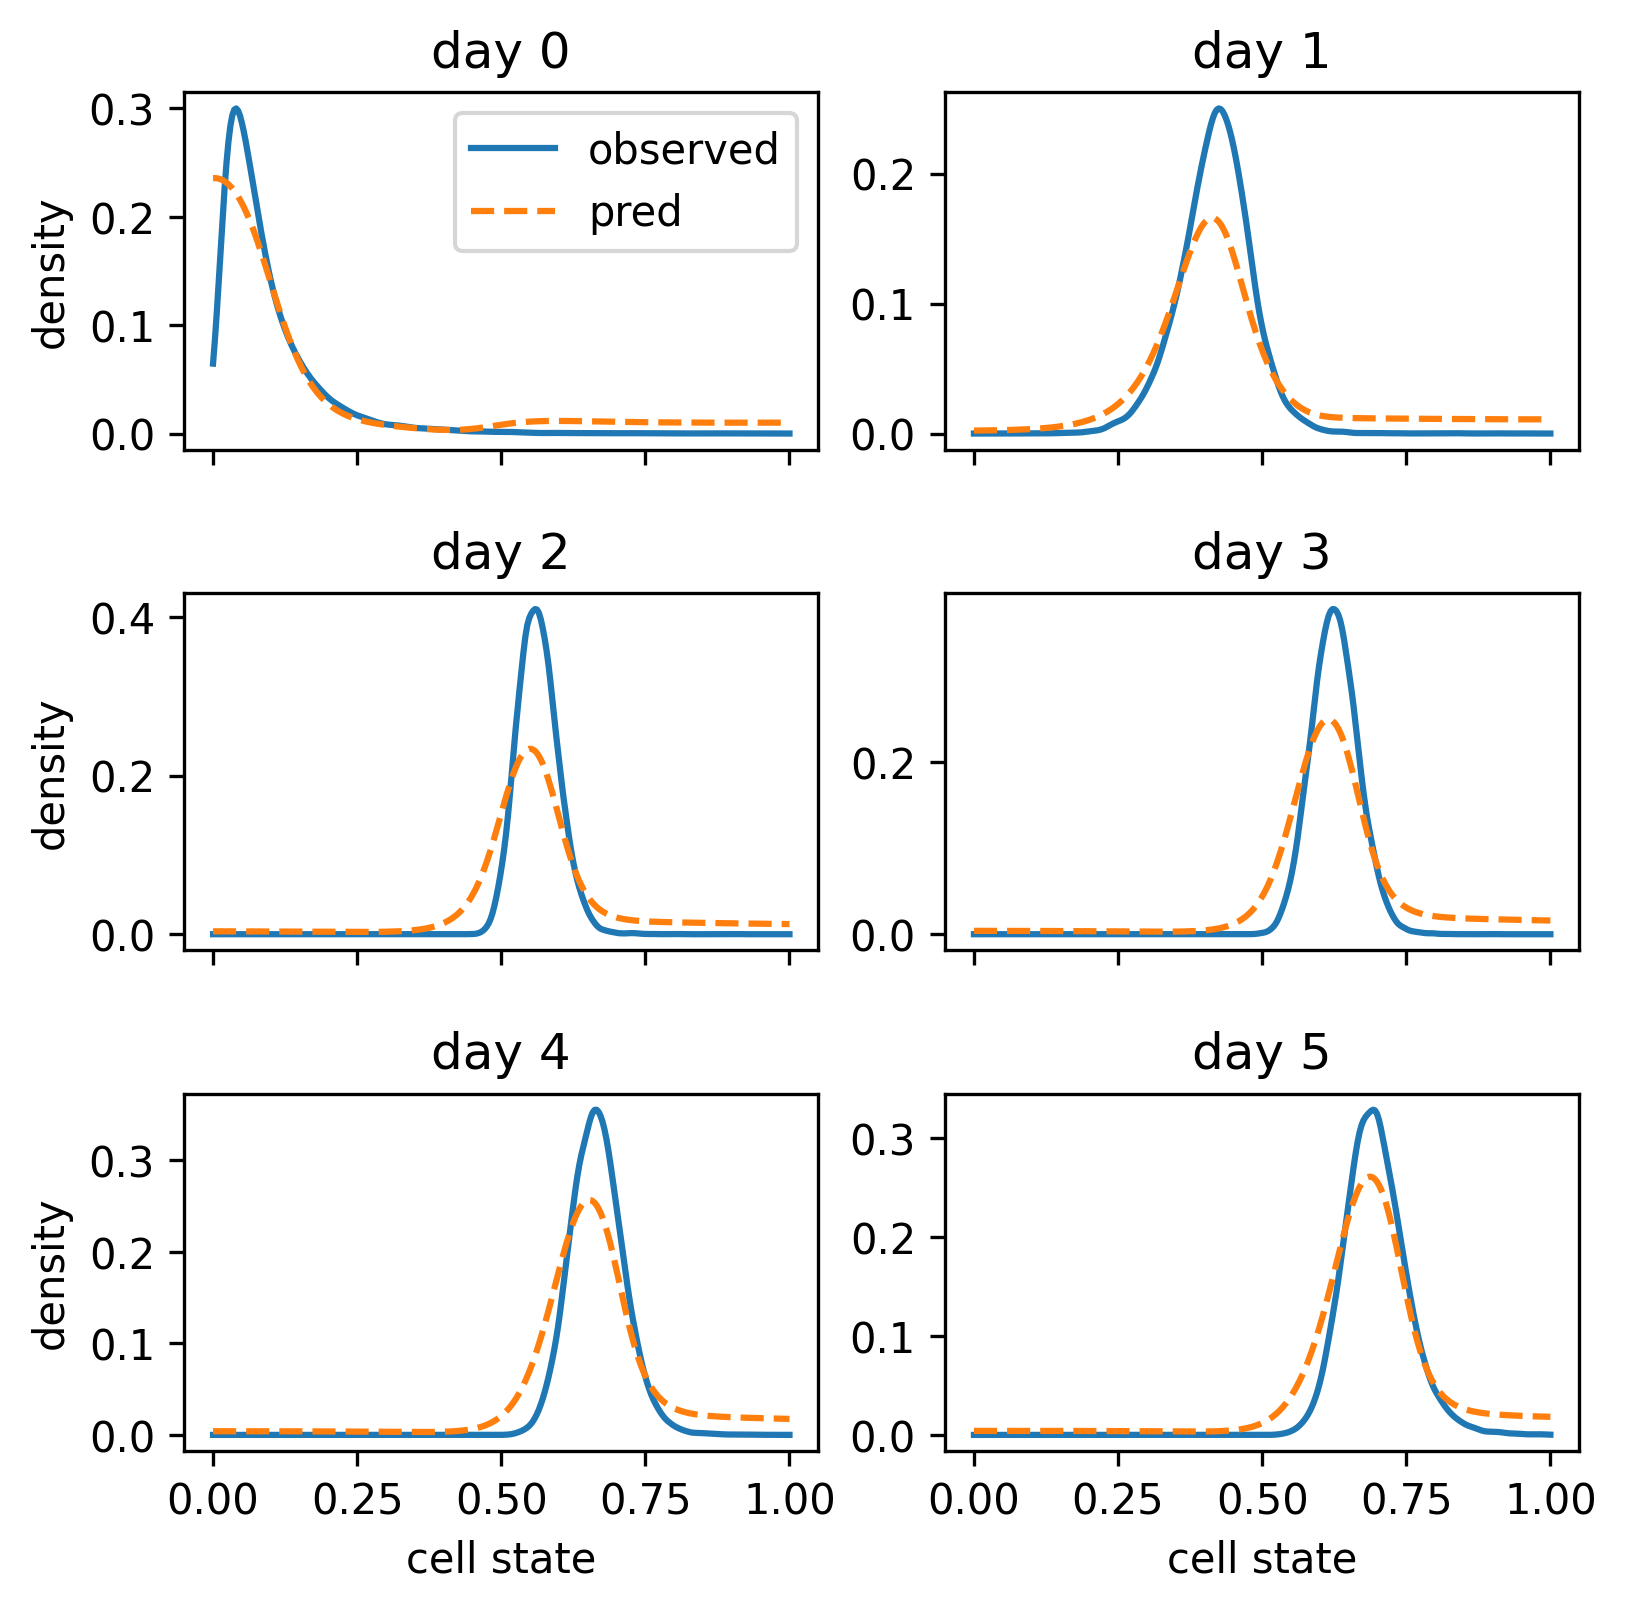

In [18]:
u_pred_b = pl_fun.predict_and_vis(modelv0, data_batch, train_DS)

# version 5

In [17]:
u_pred_b = pl_fun.predict_and_vis(modelv5, data_batch, train_DS)

NameError: name 'modelv5' is not defined